In [3]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score

# PCA
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# App User Behavior Segmentation

**Objective:** group users by usage behavior with K-Means, inspect whether the groups are meaningfully separated, and translate the resulting profiles into possible product and retention actions.

This notebook uses the supplied 50,000-row dataset. Cluster IDs are arbitrary; interpret groups from their measured profiles, not from the numeric IDs.

## Load and inspect the data


In [4]:
df = pd.read_csv("app_user_behavior_dataset.csv")
df

,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149995,23,Male,Germany,Android,1.1,10,8.68,70.21,15,...,9,Free,4,0,1,4.0,0.39,68.97,121,Google Ads
49996,149996,34,Female,India,iOS,1.1,6,3.30,41.51,9,...,10,Basic,5,5,1,5.0,0.12,64.84,133,Google Ads
49997,149997,43,Male,India,iOS,1.2,6,21.67,58.00,9,...,27,Free,9,1,2,1.0,0.60,69.70,1120,Google Ads
49998,149998,41,Male,India,iOS,1.2,13,14.29,37.93,10,...,11,Free,6,2,2,4.0,0.22,71.00,1175,Google Ads


In [5]:
df.head()
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  str    
 3   country                        50000 non-null  str    
 4   device_type                    50000 non-null  str    
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       50000 non-null  int64  
 1

(50000, 25)

In [6]:
df.describe()

,user_id,age,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,44978.000000,50000.000000,50000.000000,50000.000000
mean,124999.500000,38.513040,1.476126,7.999680,13.149842,45.164537,12.013920,4.99662,3.999060,13.470760,0.397520,0.19666,22.038240,5.995800,3.002260,2.001440,3.630664,0.500834,64.940409,603.785100
std,14433.901067,12.094948,0.470158,2.829438,8.946944,19.505118,3.480289,2.23518,1.997763,6.343635,0.633992,0.44442,12.985237,2.453313,1.731818,1.413435,1.087339,0.288578,14.838827,345.567524
min,100000.000000,18.000000,1.000000,0.000000,0.060000,5.000000,1.000000,0.00000,0.000000,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,10.000000,7.000000
25%,112499.750000,28.000000,1.100000,6.000000,6.570000,31.650000,10.000000,3.00000,3.000000,8.000000,0.000000,0.00000,11.000000,4.000000,2.000000,1.000000,3.000000,0.250000,54.900000,302.000000
50%,124999.500000,39.000000,1.200000,8.000000,11.240000,45.210000,12.000000,5.00000,4.000000,13.000000,0.000000,0.00000,22.000000,6.000000,3.000000,2.000000,4.000000,0.500000,65.025000,604.000000
75%,137499.250000,49.000000,2.000000,10.000000,17.570000,58.440000,14.000000,6.00000,5.000000,19.000000,1.000000,0.00000,33.000000,8.000000,4.000000,3.000000,4.000000,0.750000,75.090000,906.000000
max,149999.000000,59.000000,2.100000,26.000000,91.400000,129.130000,28.000000,16.00000,19.000000,24.000000,5.000000,4.00000,44.000000,19.000000,13.000000,11.000000,5.000000,1.000000,100.000000,1199.000000


## Data quality and preparation

Check missing values, data types, and duplicate records before clustering. The modeling features below are numerical behavior measures; user identifiers and categorical attributes are excluded from the distance calculation.


In [7]:
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
country                             0
device_type                         0
app_version                         0
sessions_per_week                   0
avg_session_duration_min            0
daily_active_minutes                0
feature_clicks_per_session          0
notifications_opened_per_week       0
in_app_search_count                 0
pages_viewed_per_session            0
crash_events_last_30_days           0
support_tickets_raised              0
days_since_last_login               0
subscription_type                   0
ads_clicked_last_30_days            0
content_downloads                   0
social_shares                       0
rating_given                     5022
churn_risk_score                    0
engagement_score                    0
account_age_days                    0
marketing_source                    0
dtype: int64

In [8]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [9]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [10]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


## Exploratory data analysis

Review the distributions and numeric correlations to understand the population and spot redundant behavior measures.


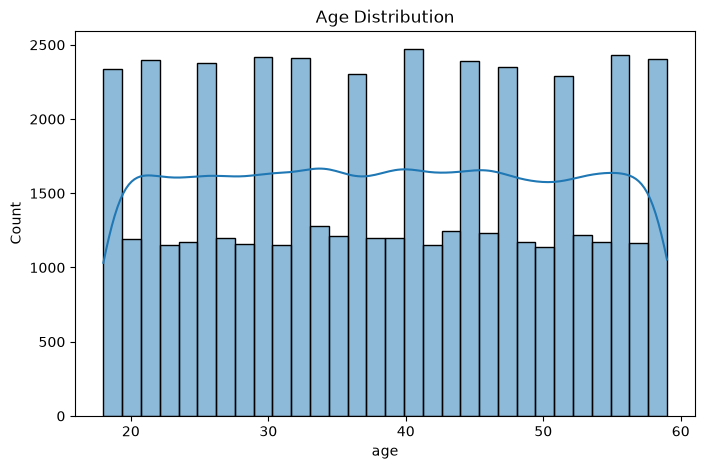

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

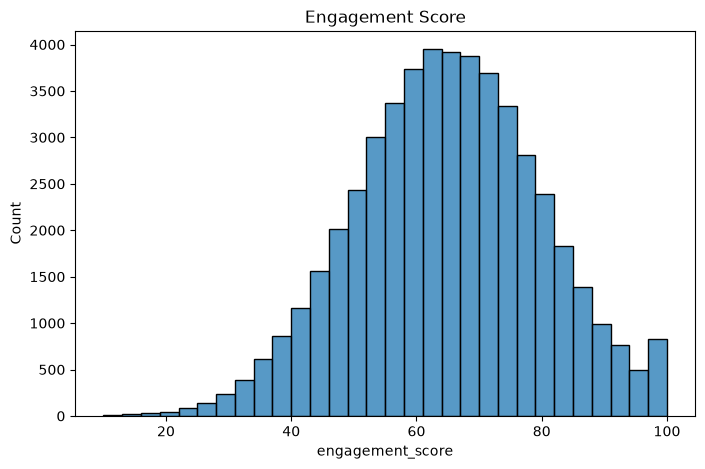

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['engagement_score'], bins=30)
plt.title('Engagement Score')
plt.show()

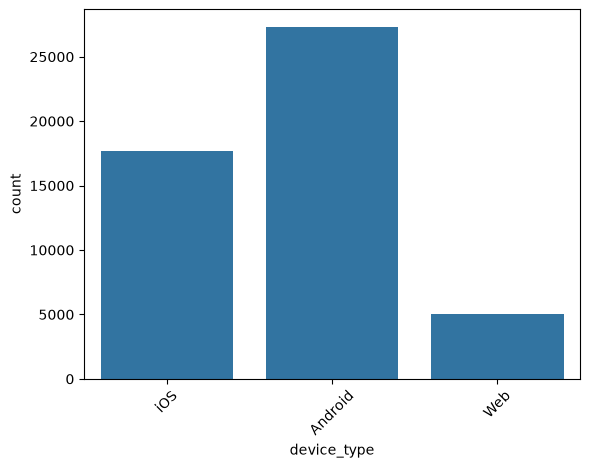

In [13]:
sns.countplot(x='device_type', data=df)
plt.xticks(rotation=45)
plt.show()

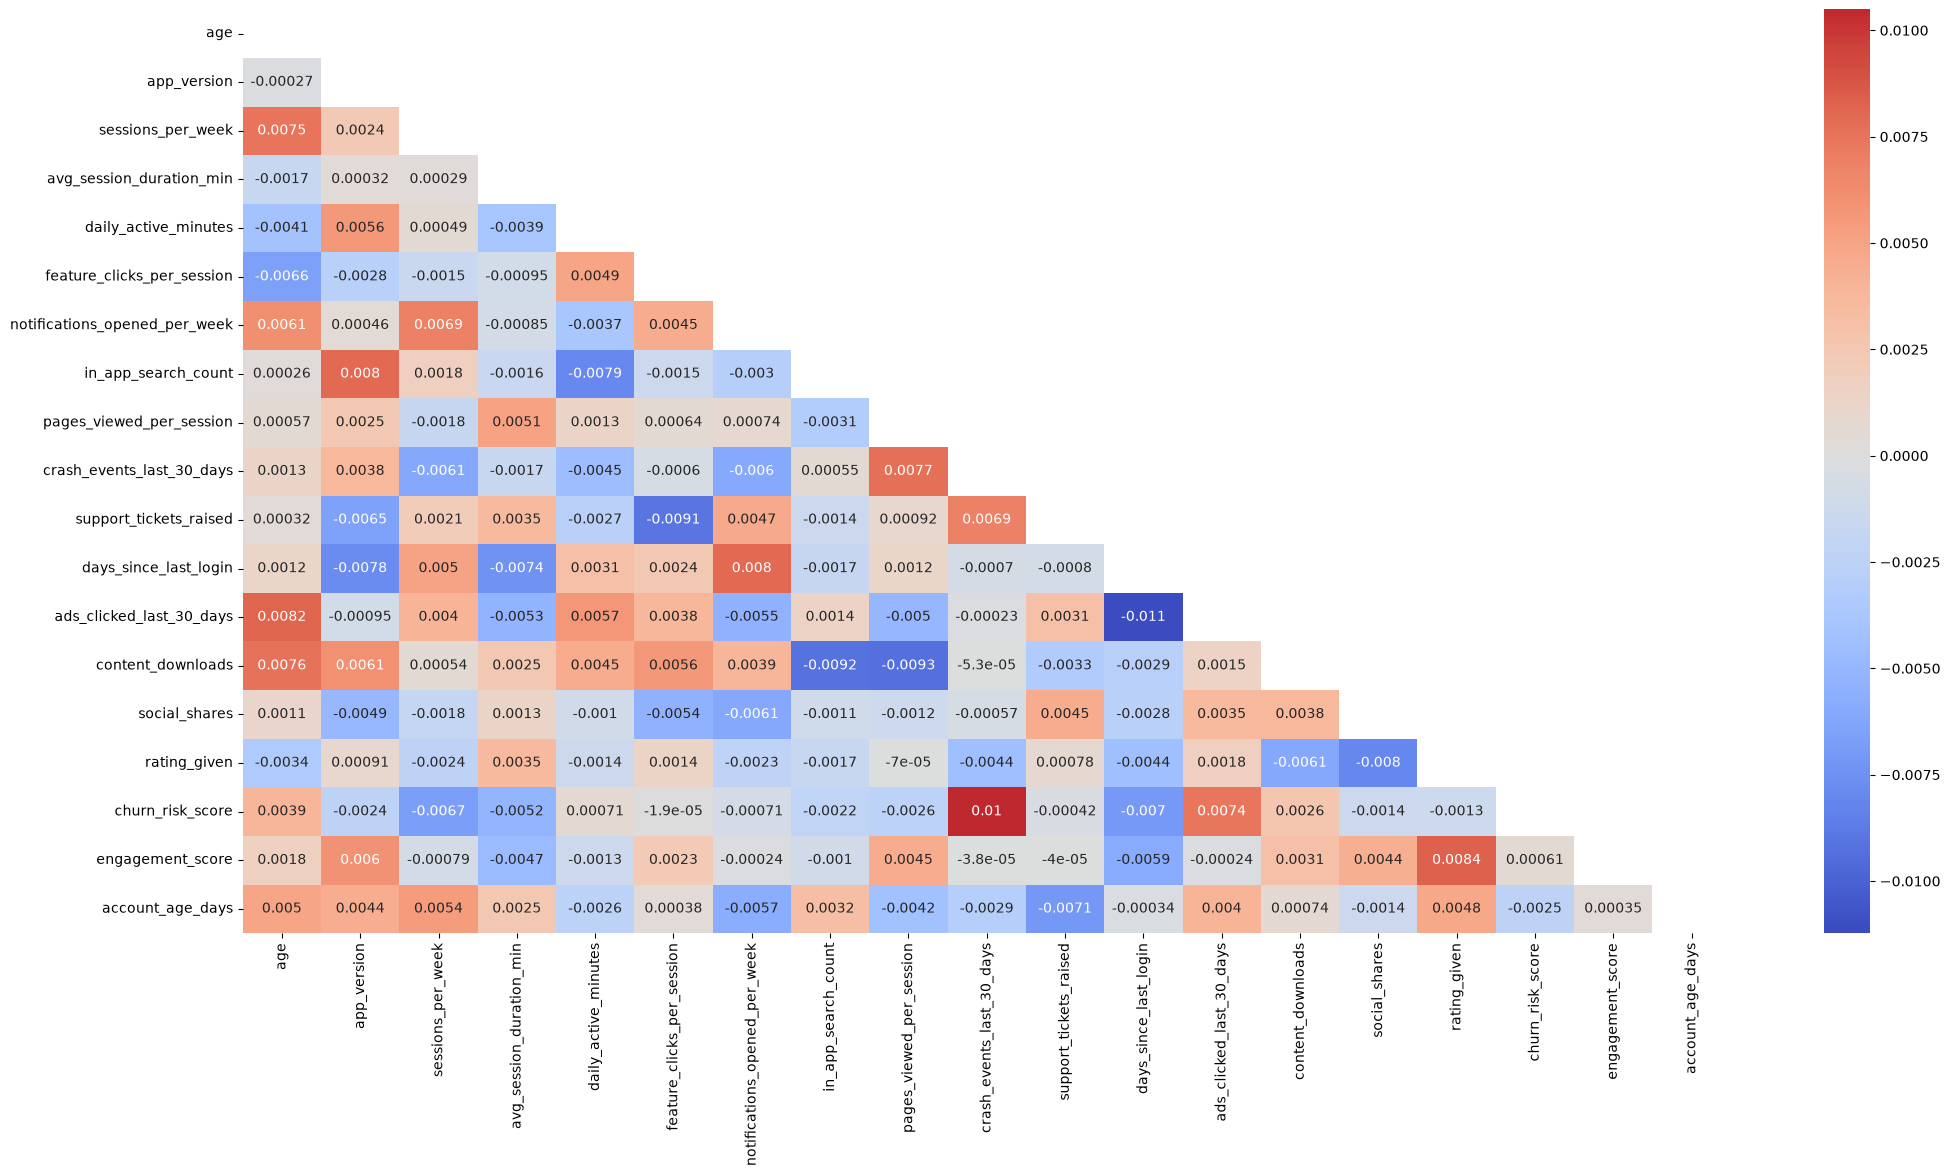

In [14]:
corr = df.select_dtypes(include=np.number).drop(columns=["user_id"], errors="ignore").corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(24, 12))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", center=0)
plt.show()

## Feature selection and scaling

The selected features represent session frequency and duration, activity, feature use, recency, engagement, and churn risk. Standardization is required because these measures use different units.


In [15]:
features = [
    'sessions_per_week',
    'daily_active_minutes',
    'days_since_last_login',
    'engagement_score','churn_risk_score'
]

In [16]:
X = df[features]

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Choose and evaluate a cluster count

Use the elbow curve and sampled silhouette scores together. The best silhouette score is only a comparison among the tested values: low scores indicate overlapping groups and should temper any claim that clusters are clearly separated. The four-cluster solution below is retained as a project comparison; review it against the score table before treating four as definitive.


In [18]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

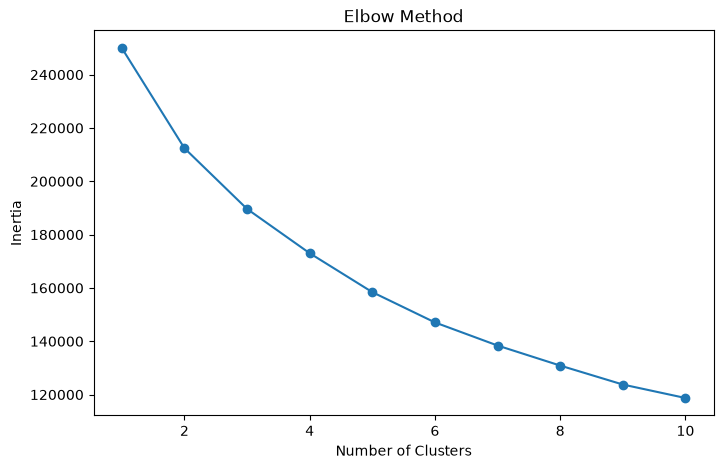

In [19]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## Provisional four-cluster solution

The original analysis fits four clusters. The following sections profile those groups, visualize their separation, and create business-facing outputs.


In [20]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [21]:
df['Cluster'].value_counts()

Cluster
0    12730
1    12455
3    12439
2    12376
Name: count, dtype: int64

In [22]:
score = silhouette_score(
    X_scaled,
    df['Cluster'],
    sample_size=5000,
    random_state=42
)

print("Silhouette Score:", score)

Silhouette Score: 0.14140963152324168


In [23]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels, sample_size=min(5000, len(X_scaled)), random_state=42)

    scores.append(score)

    print(f"K={k}, Score={score:.4f}")

K=2, Score=0.1545
K=3, Score=0.1429
K=4, Score=0.1414
K=5, Score=0.1465
K=6, Score=0.1461
K=7, Score=0.1417
K=8, Score=0.1464
K=9, Score=0.1501
K=10, Score=0.1500


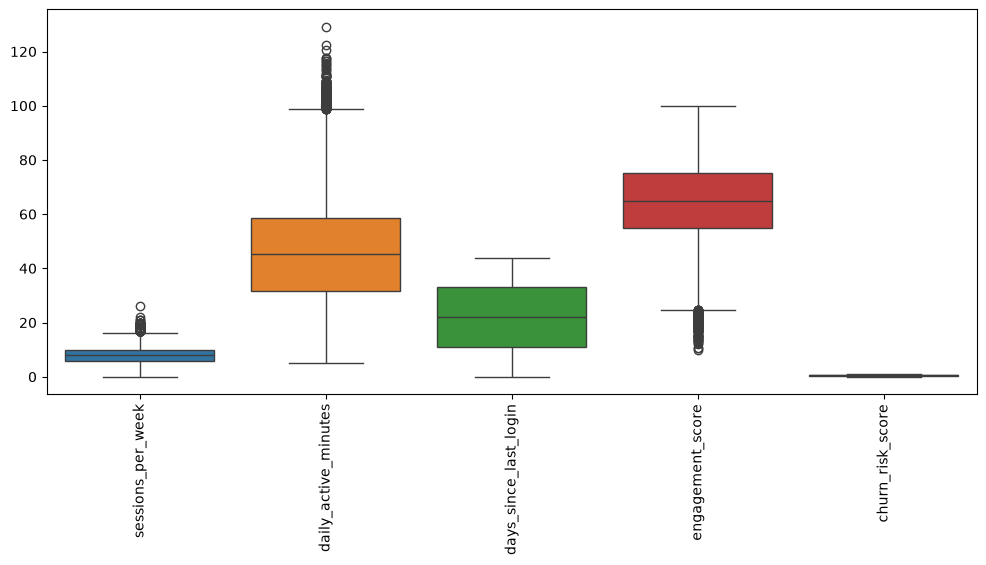

In [24]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df[features])
plt.xticks(rotation=90)
plt.show()

## Compare candidate counts

This table makes the score-based recommendation explicit. Because the scores in the saved run were low, treat the selected count as provisional and use the elbow plot plus profile usefulness to make the final choice.


In [25]:
score_table = pd.DataFrame({
    "k": list(range(2, 11)),
    "silhouette": scores
}).sort_values("silhouette", ascending=False).reset_index(drop=True)

display(score_table)
print(f"Highest sampled silhouette among tested values: k={int(score_table.loc[0, 'k'])} "
      f"(score={score_table.loc[0, 'silhouette']:.4f})")
print("The four-cluster model below is a project comparison. Keep it only if the elbow, profiles, and intended business use support it.")


,k,silhouette
0,2,0.154464
1,9,0.150149
2,10,0.150023
3,5,0.146500
4,8,0.146359
5,6,0.146100
6,3,0.142944
7,7,0.141717
8,4,0.141410


Highest sampled silhouette among tested values: k=2 (score=0.1545)
The four-cluster model below is a project comparison. Keep it only if the elbow, profiles, and intended business use support it.


## PCA view of the four-cluster solution

PCA reduces the scaled feature space to two dimensions for visualization. It is a diagnostic view, not proof of cluster quality; overlapping points are evidence that the segmentation is not sharply separated.


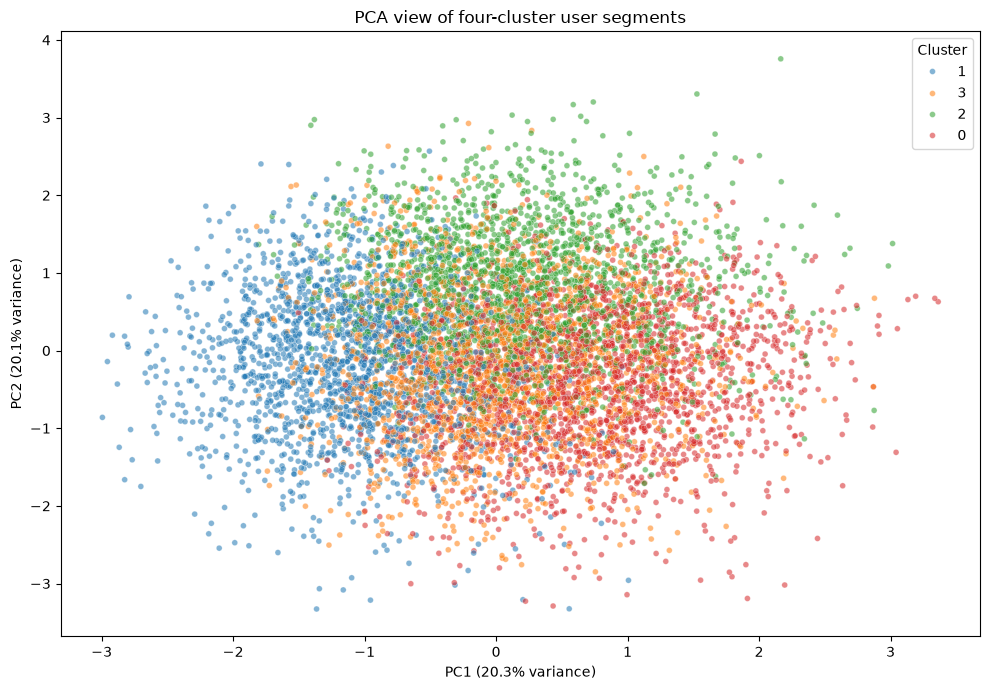

Variance explained by first two components: 40.3%


In [26]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": df["Cluster"].astype(str).to_numpy()
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df.sample(n=min(8000, len(pca_df)), random_state=42),
                x="PC1", y="PC2", hue="Cluster",
                palette="tab10", alpha=0.55, s=18)
plt.title("PCA view of four-cluster user segments")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()
print(f"Variance explained by first two components: {pca.explained_variance_ratio_.sum():.1%}")


## Profile and describe each cluster

Review the actual means and distributions before assigning final segment names. The profile combines cluster size with the same behavior measures used for clustering.


,users,share_pct,sessions_per_week,daily_active_minutes,days_since_last_login,engagement_score,churn_risk_score
Cluster,,,,,,,
0,12730,25.5,7.99,44.67,32.39,71.99,0.27
1,12455,24.9,7.78,44.68,12.74,74.33,0.73
2,12376,24.8,8.10,45.58,31.78,55.83,0.73
3,12439,24.9,8.12,45.75,11.06,57.39,0.29


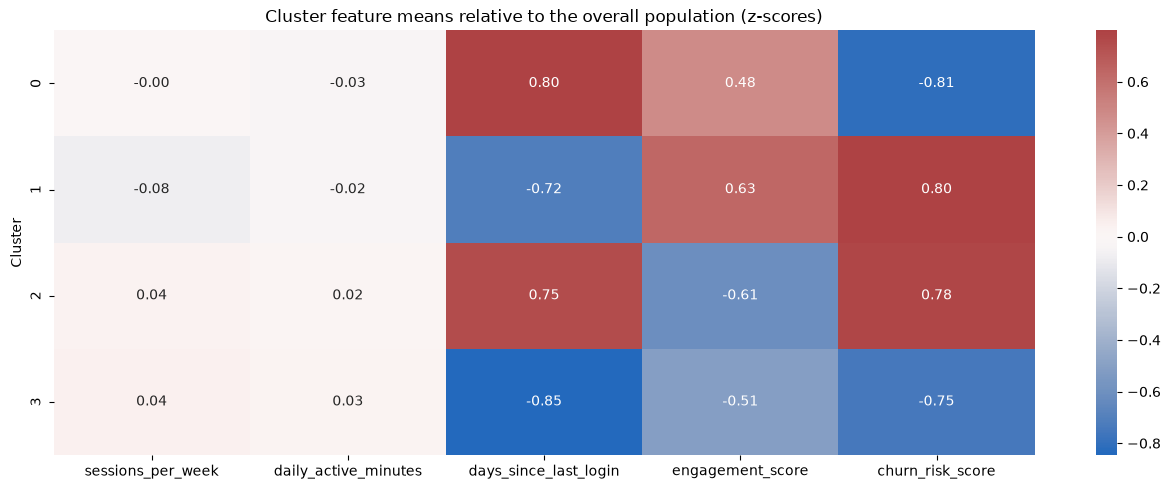

In [27]:
profile_features = features
cluster_sizes = df["Cluster"].value_counts().sort_index().rename("users")
cluster_profile = df.groupby("Cluster")[profile_features].mean().round(2)
cluster_profile.insert(0, "users", cluster_sizes)
cluster_profile.insert(1, "share_pct", (cluster_sizes / len(df) * 100).round(1))
display(cluster_profile)

# A standardized heatmap helps compare each cluster with the overall average.
profile_z = (df.groupby("Cluster")[profile_features].mean() - df[profile_features].mean()) / df[profile_features].std(ddof=0)
plt.figure(figsize=(13, 5))
sns.heatmap(profile_z, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Cluster feature means relative to the overall population (z-scores)")
plt.tight_layout()
plt.show()


## Assign readable segment descriptions and actions

These labels and actions are generated from the profiles using relative engagement, inactivity, and churn-risk levels. Review the displayed profile alongside these suggestions and adjust the wording to match what the data actually shows. They are hypotheses for business use, not causal findings.


In [28]:
median_engagement = cluster_profile["engagement_score"].median()
median_churn = cluster_profile["churn_risk_score"].median()
median_inactive_days = cluster_profile["days_since_last_login"].median()

def describe_segment(row):
    high_engagement = row["engagement_score"] >= median_engagement
    high_churn = row["churn_risk_score"] >= median_churn
    inactive = row["days_since_last_login"] >= median_inactive_days
    if high_engagement and not high_churn:
        return pd.Series(["High engagement / lower risk", "Reward loyalty; test premium or referral offers."])
    if not high_engagement and inactive:
        return pd.Series(["Occasional / inactive", "Use a gentle reactivation message and highlight relevant features."])
    if high_churn:
        return pd.Series(["At-risk users", "Prioritize retention outreach; investigate friction and support needs."])
    return pd.Series(["Moderate / steady users", "Personalize discovery prompts and encourage useful repeat activity."])

cluster_profile[["segment", "suggested_action"]] = cluster_profile.apply(describe_segment, axis=1)
display(cluster_profile[["users", "share_pct", "segment", "engagement_score", "churn_risk_score", "sessions_per_week", "daily_active_minutes", "days_since_last_login", "suggested_action"]])


,users,share_pct,segment,engagement_score,churn_risk_score,sessions_per_week,daily_active_minutes,days_since_last_login,suggested_action
Cluster,,,,,,,,,
0,12730,25.5,High engagement / lower risk,71.99,0.27,7.99,44.67,32.39,Reward loyalty; test premium or referral offers.
1,12455,24.9,At-risk users,74.33,0.73,7.78,44.68,12.74,Prioritize retention outreach; investigate fri...
2,12376,24.8,Occasional / inactive,55.83,0.73,8.10,45.58,31.78,Use a gentle reactivation message and highligh...
3,12439,24.9,Moderate / steady users,57.39,0.29,8.12,45.75,11.06,Personalize discovery prompts and encourage us...


## Customer-level assignments and deliverables

Export a compact user-to-cluster file so each user can be identified for a targeted action. The segment description is joined to each assigned user.


In [29]:
segment_lookup = cluster_profile[["segment", "suggested_action"]]
user_assignments = df[["user_id", "Cluster"]].copy()
user_assignments = user_assignments.join(segment_lookup, on="Cluster")

output_path = "app_user_behavior_cluster_assignments.csv"
user_assignments.to_csv(output_path, index=False)
print(f"Saved {len(user_assignments):,} user assignments to: {output_path}")
display(user_assignments.head())


Saved 50,000 user assignments to: app_user_behavior_cluster_assignments.csv


,user_id,Cluster,segment,suggested_action
0,100000,3,Moderate / steady users,Personalize discovery prompts and encourage us...
1,100001,1,At-risk users,Prioritize retention outreach; investigate fri...
2,100002,2,Occasional / inactive,Use a gentle reactivation message and highligh...
3,100003,3,Moderate / steady users,Personalize discovery prompts and encourage us...
4,100004,3,Moderate / steady users,Personalize discovery prompts and encourage us...


## Conclusion checklist

This project successfully applied K-Means clustering to segment app users based on their behavioural and engagement patterns. After data preprocessing, feature scaling, clustering, and PCA visualization, distinct user groups were identified and profiled. The insights generated can help businesses improve user engagement, reduce churn, and implement targeted marketing and retention strategies. Overall, the project demonstrates the practical use of unsupervised machine learning for data-driven decision-making.
